## Import Library

In [76]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
import yaml

with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [78]:
data_path = "../data/processed/final_dataset.csv"

df = pd.read_csv(data_path)

df.head()

,ip,method,endpoint,status,endpoint_length,param_count,has_query,attack,has_sql,has_script,has_path_traversal,req_key
0,175.45.188.252,POST,/api/v1/auths/login,401,19,0,0,1,0,0,0,175.45.188.252POST/api/v1/auths/login00
1,175.45.188.252,POST,/api/v1/auths/login,200,19,0,0,1,0,0,0,175.45.188.252POST/api/v1/auths/login00
2,175.45.188.252,POST,/api/v1/auths/login,401,19,0,0,1,0,0,0,175.45.188.252POST/api/v1/auths/login00
3,175.45.188.252,POST,/api/v1/auths/login,200,19,0,0,1,0,0,0,175.45.188.252POST/api/v1/auths/login00
4,175.45.188.252,POST,/api/v1/auths/login,401,19,0,0,1,0,0,0,175.45.188.252POST/api/v1/auths/login00


In [79]:
df['attack'].value_counts()

attack
1    20008
0     1529
Name: count, dtype: int64

In [80]:
df = df.drop(columns=["req_key"])

In [81]:
features = [
    "endpoint_length",
    "has_sql",
    "has_script",
    "has_path_traversal",
    "param_count",
    "has_query"
]

X = df[features]

y = df["attack"]

In [82]:
test_size = config["model"]["test_size"]
random_state = config["model"]["random_state"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=random_state,
    stratify=y
)

In [83]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (17229, 6)
Test size: (4308, 6)


In [84]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [85]:
y_pred = model.predict(X_test)

In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.25      0.37       306
           1       0.95      0.99      0.97      4002

    accuracy                           0.94      4308
   macro avg       0.80      0.62      0.67      4308
weighted avg       0.92      0.94      0.92      4308



In [87]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9370937790157846


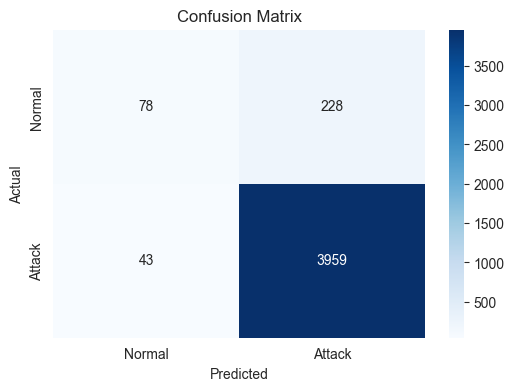

In [88]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [89]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": importance
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
0,endpoint_length,0.696920
4,param_count,0.159962
5,has_query,0.113102
1,has_sql,0.030015
3,has_path_traversal,0.000000
2,has_script,0.000000


In [90]:
import joblib

model_path = "../models/attack_detection_model.pkl"

joblib.dump(model, model_path)

print("Model saved to:", model_path)

Model saved to: ../models/attack_detection_model.pkl


In [91]:
# fitur yang digunakan model
features = [
    "endpoint_length",
    "has_sql",
    "has_script",
    "has_path_traversal",
    "param_count",
    "has_query"
]

# beberapa sample request
samples = pd.DataFrame([
    [10, 0, 0, 0, 2, 1],  # normal request
    [22, 1, 1, 1, 1, 1],  # SQL injection
    [24, 0, 1, 0, 1, 1],  # XSS attack
    [32, 0, 0, 1, 1, 1],  # Path traversal
], columns=features)

# prediksi
predictions = model.predict(samples)

# tampilkan hasil
for i, pred in enumerate(predictions):
    label = "Attack" if pred == 1 else "Normal"
    print(f"Sample {i+1} Prediction: {label}")

Sample 1 Prediction: Normal
Sample 2 Prediction: Attack
Sample 3 Prediction: Normal
Sample 4 Prediction: Normal
